In [1]:
from transformers import AutoTokenizer, AutoModel
import gensim.downloader as api
import torch
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import PCA

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from numpy import dot
from numpy.linalg import norm

/home/asus/miniconda3/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Introduction

NLP models such as BERT, GPT and T5 rely on 2 fundamental steps to process text:
* Tokenization: splitting text into smaller units (words, sub-words or even characters)
* Embedding: convert tokens into numerical representations

This notebook explores:
* Differences between tokenization methods
* Their impact on sequence length and representation

## 2. Tokenization comparison

In [2]:
# Load tokenizer

# WordPiece
bert_tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

# BPE
gpt2_tokenizer = AutoTokenizer.from_pretrained("gpt2")

# SentencePiece
t5_tokenizer = AutoTokenizer.from_pretrained("t5-small")

In [3]:
# Define sentences

sentences = [
    "I love machine learning",
    "The bank is near the river",
    "AI is revolutionizing our lives"
]

In [4]:
# Apply tokenization

results = []

for sentence in sentences:

    bert_tokens = bert_tokenizer.tokenize(sentence)
    gpt2_tokens = gpt2_tokenizer.tokenize(sentence)
    t5_tokens = t5_tokenizer.tokenize(sentence)

    results.append({
        "Sentence": sentence,
        "BERT (WordPiece)": bert_tokens,
        "GPT2 (BPE)": gpt2_tokens,
        "T5 (SentencePiece)": t5_tokens
    })

df = pd.DataFrame(results)
df

,Sentence,BERT (WordPiece),GPT2 (BPE),T5 (SentencePiece)
0,I love machine learning,"[i, love, machine, learning]","[I, Ġlove, Ġmachine, Ġlearning]","[▁I, ▁love, ▁machine, ▁learning]"
1,The bank is near the river,"[the, bank, is, near, the, river]","[The, Ġbank, Ġis, Ġnear, Ġthe, Ġriver]","[▁The, ▁bank, ▁is, ▁near, ▁the, ▁river]"
2,AI is revolutionizing our lives,"[ai, is, revolution, ##izing, our, lives]","[AI, Ġis, Ġrevolution, izing, Ġour, Ġlives]","[▁AI, ▁is, ▁revolution, izing, ▁our, ▁lives]"


* All the models use sub-words (look at revolution+izing) when there are complex words
* WordPiece uses ## to indicate continuation and makes lowercasin (AI becomes ai)
* BPE is case-sensitive and uses Ġ to indicate the space
* SentencePiece uses _ to indicate the beginning of the word, and doesn't really considers white spaces

## 3. Static Embeddings (GloVe)

It assigns a single vector to each word, independently on the context.

In [5]:
model_static = api.load("glove-wiki-gigaword-100")

In [6]:
# Cosine similarity function

def cosine_similarity(vec_1, vec_2):
    return dot(vec_1, vec_2) / (norm(vec_1) * norm(vec_2))

In [7]:
# Similarity between words

words = ["bank", "money", "river", "finance"]

for w in words:
    print(f"{w} -> vector norm: {norm(model_static[w]):.4f}")

bank -> vector norm: 6.8118
money -> vector norm: 6.0408
river -> vector norm: 7.2637
finance -> vector norm: 6.0834


In [8]:
print("bank vs money:", cosine_similarity(model_static["bank"], model_static["money"]))
print("bank vs river:", cosine_similarity(model_static["bank"], model_static["river"]))
print("money vs finance:", cosine_similarity(model_static["money"], model_static["finance"]))

bank vs money: 0.57181627
bank vs river: 0.33449313
money vs finance: 0.5676939


In [9]:
model_static.most_similar("bank", topn=5)

[('banks', 0.8057132959365845),
 ('banking', 0.7530707120895386),
 ('credit', 0.7037603259086609),
 ('investment', 0.6939943432807922),
 ('financial', 0.6777413487434387)]

* GloVe assigns a single embedding to each word
* As an example, the word "bank" has just one representation, independently on the context -> Limitation of static embedding

## 4. Contextual Embeddings (BERT)

Contextual embeddings depend on the input sentence. Models like BERT can generate different word representations for the same word, depending on the context.

In [10]:
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")
model_contextual = AutoModel.from_pretrained("bert-base-uncased")

model_contextual.eval()

Loading weights: 100%|█████████████████████| 199/199 [00:00<00:00, 15596.58it/s]
BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


BertModel(
  (embeddings): BertEmbeddings(
    (word_embeddings): Embedding(30522, 768, padding_idx=0)
    (position_embeddings): Embedding(512, 768)
    (token_type_embeddings): Embedding(2, 768)
    (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (encoder): BertEncoder(
    (layer): ModuleList(
      (0-11): 12 x BertLayer(
        (attention): BertAttention(
          (self): BertSelfAttention(
            (query): Linear(in_features=768, out_features=768, bias=True)
            (key): Linear(in_features=768, out_features=768, bias=True)
            (value): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (output): BertSelfOutput(
            (dense): Linear(in_features=768, out_features=768, bias=True)
            (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
            (dropout): Dropout(p=0.1, inplace=False)
  

In [11]:
# Sentences

s1 = "I went to the bank"
s2 = "The river bank is calm"

In [12]:
# Function to extract word embedding

def get_word_embedding(sentence, target_word):

    inputs = tokenizer(sentence, return_tensors="pt")

    with torch.no_grad():
        outputs = model_contextual(**inputs)

    tokens = tokenizer.convert_ids_to_tokens(inputs["input_ids"][0])
    embeddings = outputs.last_hidden_state[0]

    target_indices = []

    for i, tok in enumerate(tokens):
        clean_tok = tok.replace("##", "")
        if clean_tok == target_word:
            target_indices.append(i)

    if len(target_indices) == 0:
        print(f"'{target_word}' not found in: ", tokens)
        return None, tokens

    # If more subwords -> average embeddings
    target_embedding = embeddings[target_indices].mean(dim=0)

    return target_embedding.numpy(), tokens

In [13]:
emb1, tokens1 = get_word_embedding(s1, "bank")
emb2, tokens2 = get_word_embedding(s2, "bank")

print("Sentence 1 tokens:", tokens1)
print("Sentence 2 tokens:", tokens2)

Sentence 1 tokens: ['[CLS]', 'i', 'went', 'to', 'the', 'bank', '[SEP]']
Sentence 2 tokens: ['[CLS]', 'the', 'river', 'bank', 'is', 'calm', '[SEP]']


In [14]:
# Similarity

sim = cosine_similarity(emb1, emb2)
print("Cosine similarity between 'bank' embeddings:", sim)

Cosine similarity between 'bank' embeddings: 0.41381946


* The word "bank" has different embeddings, depending on the context
* Cosine similarity is < 1, indicating different representations

## 5. PCA

I project high dimensional vectors into 2D space using PCA, comparing:
* Static embeddings (GloVe)
* Contextual embeddings (BERT)

In [15]:
# Extract embeddings from GloVe

words = ["bank", "money", "river", "finance", "water", "loan"]

word_vectors = [model_static[w] for w in words]

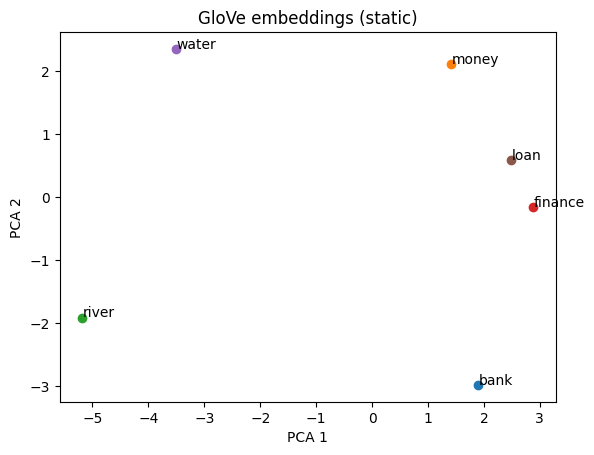

In [16]:
# PCA

pca = PCA(n_components=2)
reduced = pca.fit_transform(word_vectors)

plt.figure()

for i, word in enumerate(words):
    x, y = reduced[i]
    plt.scatter(x, y)
    plt.text(x+0.01, y+0.01, word)

plt.title("GloVe embeddings (static)")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.show()

In [17]:
# Sentences to give context to BERT

sentences = [
    "I went to the bank to deposit money",
    "The river bank is full of water",
    "He took a loan from the bank",
    "The bank approved the mortgage"
]

In [18]:
# Get embeddings for words

target_words = ["bank", "money", "river", "loan", "water", "finance"]

def get_embedding_for_word(sentence, target_word):
    inputs = tokenizer(sentence, return_tensors="pt")
    
    with torch.no_grad():
        outputs = model_contextual(**inputs)
    
    tokens = tokenizer.convert_ids_to_tokens(inputs["input_ids"][0])
    embeddings = outputs.last_hidden_state[0]
    
    indices = []
    for i, tok in enumerate(tokens):
        clean_tok = tok.replace("##", "")
        if clean_tok == target_word:
            indices.append(i)
    
    if len(indices) == 0:
        return None
    
    return embeddings[indices].mean(dim=0).numpy()

In [19]:
# Extract embeddings

bert_vectors = []
labels = []

for sentence in sentences:
    for word in target_words:
        if word in sentence.lower():
            emb = get_embedding_for_word(sentence, word)
            
            if emb is not None and not np.isnan(emb).any():
                bert_vectors.append(emb)
                labels.append(f"{word} ({sentence[:20]})")

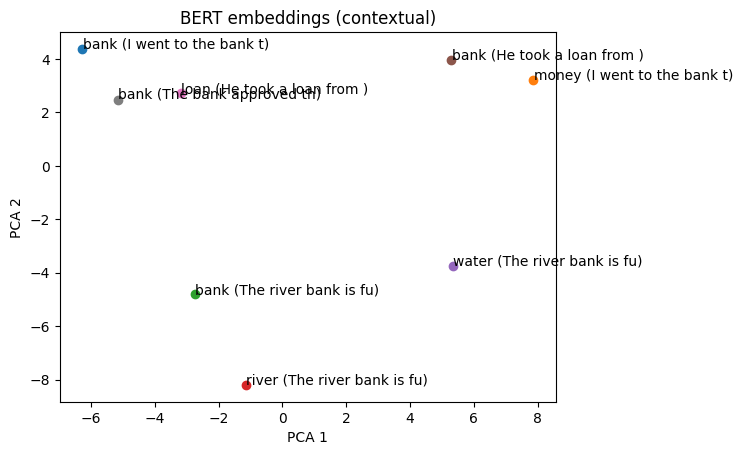

In [20]:
# PCA

bert_vectors = np.array(bert_vectors)

pca = PCA(n_components=2)
reduced_bert = pca.fit_transform(bert_vectors)

plt.figure()

for i, label in enumerate(labels):
    x, y = reduced_bert[i]
    plt.scatter(x, y)
    plt.text(x+0.01, y+0.01, label)

plt.title("BERT embeddings (contextual)")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.show()

For each sentence, I am getting a different embedding for "bank" $\rightarrow$ contextual embeddings don't represent words, but word meaning into specific contexts.
* "bank" (river context) is close to "river" and "water"
* "bank" (finance context) is close to "money" and "loan" 